# Libraries 

In [30]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated , Literal

# Setup LLM

In [31]:
import os
from dotenv import load_dotenv
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace

# load environment
load_dotenv()
# check token
token = os.getenv("HUGGINGFACEHUB_API_TOKEN")
if not token:
    print("Error: HUGGINGFACEHUB_API_TOKEN is not set in the .env file.")
else:
    print("Done")
#  Setup the Endpoint
repo_id = "meta-llama/Llama-3.1-8B-Instruct"

llm_H = HuggingFaceEndpoint(
    repo_id=repo_id,
    task="text-generation",
    max_new_tokens=512,
    temperature=0.7,
    huggingfacehub_api_token=token,
)
#  Wrap it in ChatHuggingFace (This handles the "conversational" format for you)
model = ChatHuggingFace(llm=llm_H)

Done


# Schema 

In [32]:
# For posting on Twitter 

class TwitterState(TypedDict):
    topic : str 
    tweet : str 
    evaluate : Literal['Approved', 'Rejected']
    feedback : str 
    iteration : int
    max_iteration : int 
    

# Functions for nodes 

In [33]:
def generate_tweet(state: TwitterState) -> str:
    pass 
def evaluate_tweet(state: TwitterState) -> str:
    pass 
def route_evalution():
    pass
def approved_tweet(state: TwitterState) -> str:
    pass 
def rejected_tweet(state: TwitterState) -> str:
    pass 
def optimizer_tweet(state: TwitterState) -> str:
    pass 

# Graph

In [34]:
graph = StateGraph(TwitterState)

### Nodes

In [35]:
graph.add_node("generate_tweet",generate_tweet)
graph.add_node("evaluate_tweet",evaluate_tweet)
graph.add_node("optimizer_tweet",optimizer_tweet)

### Edges

In [36]:
graph.add_edge(START, "generate_tweet")
graph.add_edge("generate_tweet", "evaluate_tweet")
graph.add_conditional_edges("evaluate_tweet", route_evalution , {"Approved": END , "Rejected" : "optimizer_tweet"})
graph.add_edge("optimizer_tweet", "evaluate_tweet")

In [38]:
workflow = graph.compile()

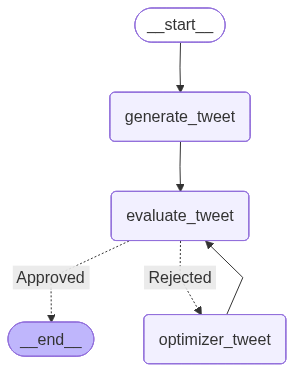

In [39]:
workflow